# Numerical Precision

In this section, you will investigate how different convolution
and matrix-matrix multiplication kernel performs when changing the
numerical precision.

## 1. Set-up

In [1]:
# Mount google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# Make sure your token is stored in a txt file at the location below.
# This way there is no risk that you will push it to your repo
# Never share your token with anyone, it is basically your github password!
with open('/content/gdrive/MyDrive/ece5545/token.txt') as f:
    token = f.readline().strip()
# Use another file to store your github username
with open('/content/gdrive/MyDrive/ece5545/git_username.txt') as f:
    handle = f.readline().strip()

In [3]:
# Clone your github repo
YOUR_TOKEN = token
YOUR_HANDLE = handle
BRANCH = "main"

%mkdir /content/gdrive/MyDrive/ece5545
%cd /content/gdrive/MyDrive/ece5545
!git clone https://{YOUR_TOKEN}@github.com/ML-HW-SYS/a4-{YOUR_HANDLE}.git
%cd /content/gdrive/MyDrive/ece5545/a4-{YOUR_HANDLE}
!git checkout {BRANCH}
!git pull

PROJECT_ROOT = f"/content/gdrive/MyDrive/ece5545/a4-{YOUR_HANDLE}"

mkdir: cannot create directory ‘/content/gdrive/MyDrive/ece5545’: File exists
/content/gdrive/MyDrive/ece5545
Cloning into 'a4-Hanfei2492'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 37 (delta 10), reused 5 (delta 5), pack-reused 14 (from 1)
Receiving objects: 100% (37/37), 3.55 MiB | 15.62 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/gdrive/MyDrive/ece5545/a4-Hanfei2492
Already on 'main'
Your branch is up to date with 'origin/main'.
Already up to date.


In [4]:
# This extension reloads all imports before running each cell
%load_ext autoreload
%autoreload 2

Verify the following cell prints your github repository.

In [5]:
!ls {PROJECT_ROOT}

1-numerical_precision.ipynb  data      README.md  tests
2-svd_rank.ipynb	     mnist.py  src


In [6]:
!pip install torch numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

# 2. Convolution

In the following cell(s), please plot the reconstruction error of an
approximated tensor (in the y-axis) with the numerical precision
(in the x-axis). Please show one plot for `winograd` and one plot for `fft`.

Winograd failed at precision torch.float64: winograd() missing 1 required positional argument: 'b'
Winograd failed at precision torch.float32: winograd() missing 1 required positional argument: 'b'
Winograd failed at precision torch.float16: winograd() missing 1 required positional argument: 'b'
Winograd failed at precision torch.bfloat16: winograd() missing 1 required positional argument: 'b'


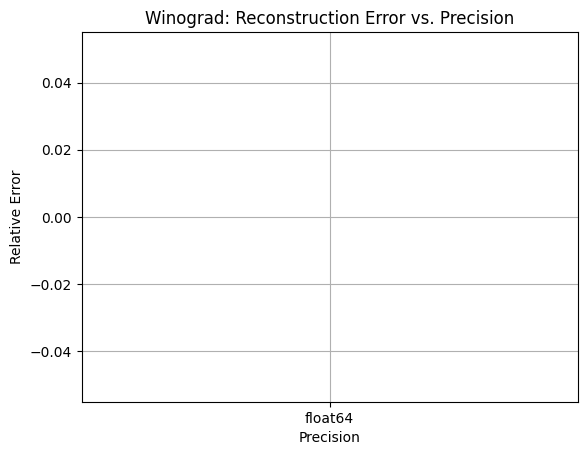

In [7]:
from src.conv2d import winograd
# TODO: plot the error v.s. precision curve
import torch
import matplotlib.pyplot as plt

# Define test input and weight
input_tensor = torch.randn(1, 3, 16, 16)
weight_tensor = torch.randn(3, 3, 3, 3)

precisions = [torch.float64, torch.float32, torch.float16, torch.bfloat16]
labels = ["float64", "float32", "float16", "bfloat16"]

def compute_error(fn, name):
    errors = []
    for dtype in precisions:
        try:
            input_ = input_tensor.to(dtype=dtype)
            weight = weight_tensor.to(dtype=dtype)

            out_custom = fn(input_, weight).to(dtype=torch.float32)
            out_naive = torch.nn.functional.conv2d(input_, weight, padding=1).to(dtype=torch.float32)

            error = torch.norm(out_custom - out_naive) / torch.norm(out_naive)
            errors.append(error.item())
        except Exception as e:
            print(f"{name} failed at precision {dtype}: {e}")
            errors.append(None)

    return errors

# Plot for Winograd
errors_winograd = compute_error(winograd, "Winograd")
plt.figure()
plt.plot(labels, errors_winograd, marker='o')
plt.title("Winograd: Reconstruction Error vs. Precision")
plt.xlabel("Precision")
plt.ylabel("Relative Error")
plt.grid(True)
plt.show()

In [ ]:
from src.conv2d import fft
# TODO: plot the error v.s. precision curve
# Plot for FFT
errors_fft = compute_error(fft, "FFT")
plt.figure()
plt.plot(labels, errors_fft, marker='o', color='orange')
plt.title("FFT: Reconstruction Error vs. Precision")
plt.xlabel("Precision")
plt.ylabel("Relative Error")
plt.grid(True)
plt.show()

# 3. Matrix-matrix Multiply

In the following cell(s), please plot the reconstruction error (in the y-axis)
with the different numerical precisions (in the x-axis) for `log` (i.e.
logorithmic matrix-matrix multiplication).

In [ ]:
from src.matmul import logmatmul

# TODO: plot the error v.s. precision curve

